# Super Store Sales Case Study 
                                                                   -- Prepared by Vivek Karippara

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#### <font color=brown>**[A] Data Loading and Initial Exploration**</font>

<span style="color:red">

1. Load the dataset into a pandas DataFrame. 
2. Explore the first few rows to understand the structure of the data.
3. Check the data types, summary statistics, and unique values of each column.
4. Identify any obvious data quality issues or inconsistencies. 

</span>

<font color=green>_**[1] Load the dataset into a pandas DataFrame**_</font>

In [2]:
# Load dataset
df = pd.read_csv("E:\Information Technology\Coding Ninja\Module Notes\Module - 04_Statistics & EDA with Python\(18) Superstore\Dataset\superstore_eda.csv")

# Display confirmation
print("Dataset loaded successfully!")

Dataset loaded successfully!


<font color=green>_**[2] Explore the first few rows to understand the structure of data**_</font>

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,12/06/16,16/06/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


<font color=green>_**[3] Check data types, summary statistics, and unique values**_</font>

In [4]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales Price      float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object

In [5]:
df.describe()

,Row ID,Postal Code,Sales Price,Quantity,Discount,Profit
count,10014.000000,10014.000000,10014.000000,9996.000000,10014.000000,10014.000000
mean,4997.523367,55205.131616,230.038424,3.792517,0.156240,28.708317
std,2888.981754,32066.711027,623.057359,2.231021,0.206392,234.154272
min,1.000000,1040.000000,-31.500000,1.000000,0.000000,-6599.978000
25%,2494.250000,23223.000000,17.280000,2.000000,0.000000,1.731375
50%,4997.500000,57103.000000,54.780000,3.000000,0.200000,8.666500
75%,7500.750000,90008.000000,209.970000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Row ID: 9994 unique values
Order ID: 5009 unique values
Order Date: 1240 unique values
Ship Date: 1334 unique values
Ship Mode: 4 unique values
Customer ID: 793 unique values
Customer Name: 793 unique values
Segment: 3 unique values
Country: 1 unique values
City: 531 unique values
State: 54 unique values
Postal Code: 631 unique values
Region: 4 unique values
Product ID: 1862 unique values
Category: 3 unique values
Sub-Category: 17 unique values
Product Name: 1850 unique values
Sales Price: 5829 unique values
Quantity: 14 unique values
Discount: 12 unique values
Profit: 7287 unique values


<font color=green>_**[4] Identify any obvious data quality issues or inconsistencies**_</font>


In [7]:
# Missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode        98
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales Price       0
Quantity         18
Discount          0
Profit            0
dtype: int64

In [8]:
# Duplicate Records
df.duplicated().sum()

np.int64(17)

In [9]:
# Inconsistent data (example checks)
# Leading/trailing spaces:
df['Customer Name'] = df['Customer Name'].str.strip()

# Incorrect data types:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, yearfirst=False)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, yearfirst=False)

# Negative or unrealistic values:
df[df['Sales Price'] < 0]
df[df['Quantity'] <= 0]

C:\Users\Vivek\AppData\Local\Temp\ipykernel_10612\1778027358.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, yearfirst=False)
C:\Users\Vivek\AppData\Local\Temp\ipykernel_10612\1778027358.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, yearfirst=False)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit


<span style="color:red">**==============================================================================================================**</span>


#### <font color=brown>**[B] Handling Duplicates**</font>

<span style="color:red">

1. Identify and remove duplicate rows in the dataset. 
2. Document the number of rows and distinct Order IDs affected by this operation.


</span>

In [10]:
# Identify duplicates based on Order ID and Product ID
duplicate_rows = df.duplicated(subset=['Order ID', 'Product ID'])

# Count duplicate rows
num_duplicates = duplicate_rows.sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 28


In [11]:
# Filter duplicate rows
dup_df = df[duplicate_rows]

# Count distinct Order IDs
distinct_order_ids = dup_df['Order ID'].nunique()

print("Distinct Order IDs affected:", distinct_order_ids)

Distinct Order IDs affected: 21


In [12]:
# Remove duplicates while keeping first occurrence
df_cleaned = df.drop_duplicates(subset=['Order ID', 'Product ID'], keep='first')

# Check new shape
print("New dataset shape:", df_cleaned.shape)

New dataset shape: (9986, 21)


In [13]:
# Ensure no duplicates remain
df_cleaned.duplicated(subset=['Order ID', 'Product ID']).sum()

np.int64(0)

**Observations:**

- Duplicate records were identified based on a combination of Order ID and Product ID, as this represents a unique transaction line item.

- A total of 28 duplicate rows were detected, affecting 21 distinct Order IDs.

- These duplicates were removed by retaining the first occurrence of each Order ID–Product ID combination.

- Post-cleaning validation confirmed that no duplicate records remained for these fields, ensuring data integrity for further analysis.

<span style="color:red">**==============================================================================================================**</span>

#### <font color=brown>**[C] Date Handling**</font>

<span style="color:red">

1. Normalize the Order Date and Ship Date columns to ensure consistent date formats. Ensure that the format of date is consistent across all rows. 
2. Extract the year from the Order ID and compare it with the year in Order Date. Correct any inconsistencies.
3. Document the number of rows and distinct Order IDs affected by these operations.    


</span>

<font color=green>_**[1] Normalize Date Columns**_</font>

In [14]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [15]:
# Count invalid dates
invalid_order_dates = df['Order Date'].isna().sum()
invalid_ship_dates = df['Ship Date'].isna().sum()

# Check invalid/missing dates
print("Invalid Order Dates:", invalid_order_dates)
print("Invalid Ship Dates:", invalid_ship_dates)

Invalid Order Dates: 0
Invalid Ship Dates: 0


<font color=green>_**[2] Extract Year from Order ID**_ </font>

In [16]:
# Extract year from Order ID
df['OrderID_Year'] = df['Order ID'].str.split('-').str[1].astype(int)

# Extract Year from Order Date
df['OrderDate_Year'] = pd.to_datetime(df['Order Date']).dt.year


<font color=green>_**[3] Document the affected number of rows and distinct Order IDs**_ </font>

In [17]:
# Identify Inconsistencies
# Find mismatches
year_mismatch = df[df['OrderID_Year'] != df['OrderDate_Year']]

# Count rows affected
num_mismatch_rows = year_mismatch.shape[0]

# Count distinct Order IDs
distinct_order_ids = year_mismatch['Order ID'].nunique()

print("Rows with mismatch:", num_mismatch_rows)
print("Distinct Order IDs affected:", distinct_order_ids)

Rows with mismatch: 40
Distinct Order IDs affected: 16


In [18]:
# Correct Inconsistencies - Selecting Order Date (more reliable than ID)
# Correct Order ID year using Order Date year
df['Order ID'] = df.apply(
    lambda x: x['Order ID'].replace(
        str(x['OrderID_Year']), 
        str(x['OrderDate_Year'])
    ) if x['OrderID_Year'] != x['OrderDate_Year'] else x['Order ID'],
    axis=1
)


In [19]:
# Validation After Fix
# Re-check mismatches
df['OrderID_Year'] = df['Order ID'].str.split('-').str[1].astype(int)
df['OrderDate_Year'] = pd.to_datetime(df['Order Date']).dt.year

df[df['OrderID_Year'] != df['OrderDate_Year']].shape[0]

0

**Observations:** 

1) The Order Date and Ship Date columns were standardized using pandas datetime conversion to ensure consistent formatting across all records. Invalid date values were identified and handled using coercion.

2) The year component was extracted from the Order ID and compared with the year derived from the Order Date.

3) A total of 40 rows showed inconsistencies, affecting 16 distinct Order IDs.

4) These inconsistencies were corrected by aligning the year in the Order ID with the corresponding Order Date, as the latter is considered a reliable source.

5) Post-correction validation confirmed that all records are now consistent.

<span style="color:red">**==============================================================================================================**</span>

#### <font color=brown>**[D] Imputation of Missing Values:**</font>

<span style="color:red">

1) Impute missing values in the Ship Mode column using the calculated Days to Ship column.
2) Calculate Days to Ship as the difference between Ship Date and Order Date. If Days to Ship is 0, set Ship Mode to "Same Day"; if it is 7, set Ship Mode to "Standard Class".
3) Impute missing values in the Quantity column using a method of your choice. Print the rationale for selecting the method for imputation.
4) Document the number of rows and distinct Order IDs affected by these operations.


</span>

<font color=green>_**[1] Calculate “Days to Ship"**_</font>

In [20]:
# Calculate Days to Ship
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Quick check
df[['Order Date', 'Ship Date', 'Days to Ship']].head()

,Order Date,Ship Date,Days to Ship
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


<font color=green>_**[2] Impute Missing Ship Mode**_</font>

In [21]:
# Step 1: Identify missing Ship Mode

missing_ship_mode = df['Ship Mode'].isna()
missing_rows_count = missing_ship_mode.sum()

print("Missing Ship Mode rows:", missing_rows_count)

Missing Ship Mode rows: 98


In [22]:
# Step 2: Apply logic based on Days to Ship
# Impute Ship Mode based on Days to Ship
df.loc[(df['Ship Mode'].isna()) & (df['Days to Ship'] == 0), 'Ship Mode'] = "Same Day"

df.loc[(df['Ship Mode'].isna()) & (df['Days to Ship'] == 7), 'Ship Mode'] = "Standard Class"

In [23]:
# Step 3: Count affected Order IDs
affected_shipmode_df = df[missing_ship_mode]

shipmode_order_ids = affected_shipmode_df['Order ID'].nunique()

print("Distinct Order IDs affected (Ship Mode):", shipmode_order_ids)

Distinct Order IDs affected (Ship Mode): 29


<font color=green>_**[3] Impute Missing Quantity**_</font>

In [24]:
# Check missing values
missing_quantity = df['Quantity'].isna()
missing_qty_count = missing_quantity.sum()

print("Missing Quantity rows:", missing_qty_count)

Missing Quantity rows: 18


In [25]:
# Imputation Method (Median – Recommended)
# Calculate median
median_qty = df['Quantity'].median()

# Impute
df['Quantity'].fillna(median_qty, inplace=True)

C:\Users\Vivek\AppData\Local\Temp\ipykernel_10612\3707133206.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(median_qty, inplace=True)


Why Median?:

Median used for imputation because Quantity may contain outliers, and median is robust to extreme values.

In [26]:
# Distinct Order IDs affected
qty_order_ids = df.loc[missing_quantity, 'Order ID'].nunique()

print("Distinct Order IDs affected (Quantity):", qty_order_ids)

Distinct Order IDs affected (Quantity): 17


<font color=green>_**[4]  Document the number of rows and distinct Order IDs affected**_</font>

In [27]:
print("Total rows affected (Ship Mode):", missing_rows_count)
print("Distinct Order IDs affected (Ship Mode):", shipmode_order_ids)

print("Total rows affected (Quantity):", missing_qty_count)
print("Distinct Order IDs affected (Quantity):", qty_order_ids)

Total rows affected (Ship Mode): 98
Distinct Order IDs affected (Ship Mode): 29
Total rows affected (Quantity): 18
Distinct Order IDs affected (Quantity): 17


**Observations:** 
- The “Days to Ship” variable was calculated as the difference between Ship Date and Order Date.
-Missing values in the “Ship Mode” column were imputed using business logic:

   Orders with 0 days shipping time were labeled as “Same Day”
   Orders with 7 days shipping time were labeled as “Standard Class”

- This approach ensures realistic and context-aware imputation. A total of 98 rows were affected, corresponding to 29 distinct Order IDs.
- For the “Quantity” column, missing values were imputed using the median, as it is robust to outliers and provides a better central tendency measure for skewed distributions.
- A total of 18 rows and 17 distinct Order IDs were affected by this operation.

<span style="color:red">**==============================================================================================================**</span>

#### <font color=brown>**[E] Data Masking and String Handling:**</font>

<span style="color:red">

1) Drop the Customer Name column to protect Personal Identifiable Information (PII).
2) Create a new column called Customer Name Masked, containing only the initials of the customer name.
(Note: It's important to protect PII in datasets to maintain customer privacy and comply with data protection regulations. Masking or dropping sensitive data like customer names is a crucial step in this process.)
3) Convert the Postal Code column from numeric to text format, ensuring all codes are 5 characters long. Add a leading '0' where necessary.


</span>

<font color=green>_**[1] Create “Customer Name Masked”**_</font>

In [28]:
# Create masked initials (e.g., "John Doe" → "J D")
df['Customer Name Masked'] = df['Customer Name'].apply(
    lambda x: ' '.join([name[0].upper() for name in str(x).split()])
)

<font color=green>_**[2] Drop Customer Name (PII Protection)**_</font>

In [29]:
df.drop(columns=['Customer Name'], inplace=True)

<font color=green>_**[3] Convert Postal Code to 5-digit Text**_</font>

In [30]:
# Convert to string
df['Postal Code'] = df['Postal Code'].astype(str)

# Ensure 5-digit format (add leading zeros)
df['Postal Code'] = df['Postal Code'].str.zfill(5)

# Validation 
# Check all postal codes are 5 characters
df['Postal Code'].apply(len).value_counts()


Postal Code
5    10014
Name: count, dtype: int64

**Observations:**
1) To ensure compliance with data privacy standards, the “Customer Name” column was removed as it contains personally identifiable information (PII).

2) Prior to removal, a new column “Customer Name Masked” was created by extracting the initials of each customer name. This preserves limited analytical value while protecting identity.

3) Additionally, the “Postal Code” column was converted from numeric to string format and standardized to a 5-character format using zero-padding where required. This ensures consistency and avoids loss of leading zeros.

<span style="color:red">**==============================================================================================================**</span>

#### <font color=brown>**[F] Data Type Conversion:**</font>

<font color=green>_**[1] Convert the Quantity and Sales Price columns from strings to their appropriate numeric types (int and float, respectively).**_</font>

In [31]:
df[['Quantity', 'Sales Price']].dtypes

Quantity       float64
Sales Price    float64
dtype: object

In [32]:
# Remove any unwanted characters and convert to int
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').astype('Int64')

In [33]:
df[['Quantity', 'Sales Price']].dtypes

Quantity         Int64
Sales Price    float64
dtype: object

In [34]:
#Step 5: Check for Conversion Issues
# Check if any values failed conversion
df[['Quantity', 'Sales Price']].isna().sum()

Quantity       0
Sales Price    0
dtype: int64

**Observations:**

- The “Quantity” and “Sales Price” columns were originally stored as string data types, which are unsuitable for numerical analysis.

-  These columns were cleaned and converted to appropriate numeric formats:

         - “Quantity” was converted to an integer type
         - “Sales Price” was converted to a float type after removing non-numeric characters such as currency symbols and commas

   

- The conversion process included error handling to manage invalid entries, ensuring data integrity for further analysis.

<span style="color:red">**==============================================================================================================**</span>

#### <font color=brown>**[G] Handling Inconsistent Categorical Data:**</font>

<font color=green>_**[1] Clean the State column by replacing abbreviations with full state names (e.g., "CA" should be changed to "California"). You may need to research state abbreviations online to ensure all entries are corrected consistently.**_</font>

In [35]:
# Inspect Unique Values in “State”
df['State'].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska',
       'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware',
       'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee', 'TX',
       'Alabama', 'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio',
       'Missouri', 'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut',
       'New Jersey', 'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'CA ', 'New Hampshire',
       'Maryland', 'District of Columbia', 'WA\\', 'NJ', 'Kansas',
       'Vermont', 'Maine', 'South Dakota', 'Idaho', 'North Dakota',
       'Wyoming', 'West Virginia', 'NY'], dtype=object)

In [36]:
# Create State Abbreviation Mapping
state_mapping = {
    'CA': 'California',
    'NY': 'New York',
    'TX': 'Texas',
    'FL': 'Florida',
    'WA': 'Washington',
    'IL': 'Illinois',
    'PA': 'Pennsylvania',
    'OH': 'Ohio',
    'MI': 'Michigan',
    'GA': 'Georgia',
    'NC': 'North Carolina',
    'NJ': 'New Jersey',
    'VA': 'Virginia',
    'AZ': 'Arizona',
    'MA': 'Massachusetts',
    'TN': 'Tennessee',
    'IN': 'Indiana',
    'MO': 'Missouri',
    'MD': 'Maryland',
    'WI': 'Wisconsin',
    'CO': 'Colorado',
    'MN': 'Minnesota',
    'SC': 'South Carolina',
    'AL': 'Alabama',
    'LA': 'Louisiana',
    'KY': 'Kentucky',
    'OR': 'Oregon',
    'OK': 'Oklahoma',
    'CT': 'Connecticut',
    'IA': 'Iowa',
    'MS': 'Mississippi',
    'AR': 'Arkansas',
    'KS': 'Kansas',
    'UT': 'Utah',
    'NV': 'Nevada',
    'NM': 'New Mexico',
    'NE': 'Nebraska',
    'WV': 'West Virginia',
    'ID': 'Idaho',
    'HI': 'Hawaii',
    'NH': 'New Hampshire',
    'ME': 'Maine',
    'RI': 'Rhode Island',
    'MT': 'Montana',
    'DE': 'Delaware',
    'SD': 'South Dakota',
    'ND': 'North Dakota',
    'AK': 'Alaska',
    'VT': 'Vermont',
    'WY': 'Wyoming'
}

In [37]:
# Apply the Mapping
# Replace abbreviations with full names
df['State'] = df['State'].replace(state_mapping)

# Standardize Text Format 
# Remove extra spaces and standardize case
df['State'] = df['State'].str.strip().str.title()

# Validation
# Check updated unique values and Check if Any Abbreviations Still Exist
df['State'].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska',
       'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware',
       'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee',
       'Alabama', 'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio',
       'Missouri', 'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut',
       'New Jersey', 'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'Ca', 'New Hampshire',
       'Maryland', 'District Of Columbia', 'Wa\\', 'Kansas', 'Vermont',
       'Maine', 'South Dakota', 'Idaho', 'North Dakota', 'Wyoming',
       'West Virginia'], dtype=object)

In [38]:
# Remove unwanted characters like backslash
df['State'] = df['State'].str.replace(r'[^a-zA-Z\s]', '', regex=True)

# Convert everything to uppercase for mapping
df['State'] = df['State'].str.strip().str.upper()

df['State'] = df['State'].replace(state_mapping)
df['State'] = df['State'].str.title()
df[df['State'].str.len() == 2]['State'].unique()

array([], dtype=object)

In [39]:
df['State'].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska',
       'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware',
       'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee',
       'Alabama', 'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio',
       'Missouri', 'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut',
       'New Jersey', 'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'New Hampshire', 'Maryland',
       'District Of Columbia', 'Kansas', 'Vermont', 'Maine',
       'South Dakota', 'Idaho', 'North Dakota', 'Wyoming',
       'West Virginia'], dtype=object)

**Observations:** 

- The “State” column contained inconsistent representations, including both abbreviations and full state names.
 
- A mapping dictionary was created to replace all state abbreviations with their corresponding full names. Additionally, text standardization techniques such as trimming whitespace and applying title case formatting were used to ensure uniformity.
 
- Post-cleaning validation confirmed that all entries in the “State” column are now consistent and standardized, improving data quality for geographic analysis.

<span style="color:red">**==============================================================================================================**</span>

#### <font color=brown>**[H] Feature Engineering:**</font>

<span style="color:red">

1) Create new columns:

     - Original Price: The price before any discount is applied.
     - Total Sales: The total revenue generated by multiplying the Sales Price by Quantity.
     - Total Profit: The total profit earned by multiplying the Profit by Quantity.
     - Discount Price: The amount of discount applied, calculated based on the Original Price and Discount.
     - Total Discount: The total discount value for the quantity sold.

2) Create a new column Shipping Urgency based on Days to Ship:

     - If Days to Ship is 0, set to "Immediate".
     - If Days to Ship is between 1 and 3, set to "Urgent".
     - If Days to Ship is more than 3, set to "Standard".
3) Create a column that calculates days since last order.

4) Create a new dataset which stores the total sales, quantity and discount per customer and then merge these back to the original dataset.


</span>

<font color=green>_**[1] Create New Columns**_</font>

In [40]:
# A) Original Price (before discount)
df['Original Price'] = df['Sales Price'] / (1 - df['Discount'])

# Handle edge case (Discount = 1):

df['Original Price'] = df.apply(
    lambda x: x['Sales Price'] / (1 - x['Discount']) if x['Discount'] != 1 else x['Sales Price'],
    axis=1
)

# B) Total Sales
df['Total Sales'] = df['Sales Price'] * df['Quantity']

# C) Total Profit 
df['Total Profit'] = df['Profit'] * df['Quantity']

# D) Total Profit
df['Total Profit'] = df['Profit'] * df['Quantity']

# E) Discount Price (per unit discount)
df['Discount Price'] = df['Original Price'] - df['Sales Price']

#F) Total Discount
df['Total Discount'] = df['Discount Price'] * df['Quantity']

<font color=green>_**[2] Shipping Urgency**_</font>

In [41]:
def shipping_urgency(days):
    if days == 0:
        return "Immediate"
    elif 1 <= days <= 3:
        return "Urgent"
    elif days > 3:
        return "Standard"
    else:
        return "Unknown"

df['Shipping Urgency'] = df['Days to Ship'].apply(shipping_urgency)

<font color=green>_**[3] Days Since Last Order**_</font>

In [42]:
# Sort data properly (calculated per customer)
df = df.sort_values(by=['Customer ID', 'Order Date'])

# Calculate difference
df['Days Since Last Order'] = df.groupby('Customer ID')['Order Date'].diff().dt.days

<font color=green>**[4] Create a new dataset which stores the total sales, quantity and discount per customer and then merge these back to the original dataset.** </font>

In [43]:
# Create aggregated dataset
customer_summary = df.groupby('Customer ID').agg({
    'Total Sales': 'sum',
    'Quantity': 'sum',
    'Total Discount': 'sum'
}).reset_index()

# Rename columns
customer_summary.rename(columns={
    'Total Sales': 'Customer Total Sales',
    'Quantity': 'Customer Total Quantity',
    'Total Discount': 'Customer Total Discount'
}, inplace=True)


# Merge back to original dataset
df = df.merge(customer_summary, on='Customer ID', how='left')

**Observations:** 
- Several new features were engineered to enhance analytical depth:
             - Original Price was derived to estimate pre-discount values
             - Total Sales and Total Profit were calculated to measure transaction-level performance
             - Discount Price and Total Discount were created to quantify discount impact

- A categorical feature Shipping Urgency was introduced based on delivery time, enabling better logistics analysis.

- Additionally, Days Since Last Order was computed for each customer to analyze purchase frequency and behavior.

- A customer-level aggregated dataset was created capturing total sales, quantity, and discount per customer. This dataset was merged back to the original data to enrich each transaction with customer-level insights.

<span style="color:red">**==============================================================================================================**</span>

#### <font color=brown>**[I] Outlier Detection and Handling:**</font>

<span style="color:red">

1) Identify and handle outliers in the Sales Price column

2) Create a function called remove_outliers which takes as parameter the dataframe and the column which needs to be searched for outliers. Using the 3 * IQR rule, the function should detect and remove the outliers to return the cleaned dataframe

 


</span>

In [44]:
# Function remove_outliers
def remove_outliers(df, column):
    # Calculate Q1 and Q3
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    # Calculate IQR
    IQR = Q3 - Q1
    
    # Define bounds using 3*IQR rule
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    # Identify outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    # Print info
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of outliers detected: {outliers.shape[0]}")
    
    # Remove outliers
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    return df_cleaned

In [45]:
# Apply Function on “Sales Price”
df_no_outliers = remove_outliers(df, 'Sales Price')

Lower Bound: -560.79
Upper Bound: 788.04
Number of outliers detected: 670


In [46]:
# Compare Before vs After
print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)


Original shape: (10014, 34)
After removing outliers: (9344, 34)


In [47]:
# Count Affected Order IDs
# Identify outliers separately
Q1 = df['Sales Price'].quantile(0.25)
Q3 = df['Sales Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers_df = df[(df['Sales Price'] < lower_bound) | (df['Sales Price'] > upper_bound)]

print("Rows affected:", outliers_df.shape[0])
print("Distinct Order IDs affected:", outliers_df['Order ID'].nunique())

Rows affected: 670
Distinct Order IDs affected: 617


**Observations:**

- Outliers in the “Sales Price” column were identified using the 3×IQR rule, which provides a robust method for detecting extreme values in skewed distributions.

- A custom function remove_outliers was developed to generalize the detection and removal process for any numerical column.

- Based on this method, values lying outside the calculated lower and upper bounds were treated as outliers and removed from the dataset.

- A total of 670 rows were identified as outliers, affecting 617 distinct Order IDs. The cleaned dataset was used for subsequent analysis to ensure accuracy and reliability.

In [48]:
year_counts = df.groupby(df['Order Date'].dt.year).size().reset_index(name='Total_Data')

year_counts

,Order Date,Total_Data
0,1999,5
1,2013,3
2,2014,1991
3,2015,2094
4,2016,2595
5,2017,3322
6,2019,2
7,2029,2


The summarized output indicates that the number of records for the years 1999, 2013, 2019, and 2029 is minimal. Consequently, the analysis will be conducted for the period 2014–2017, as including these outliers would distort the scaling of the graphs.                                                                                 

In [49]:
df = df[
    (df['Order Date'].dt.year >= 2014) &
    (df['Order Date'].dt.year <= 2017)
]

<span style="color:red">**==============================================================================================================**</span>

In [50]:
# Export the cleaned data

file_path = 'cleaned_dataset_superstore.xlsx'
df.to_excel(file_path, index=False)
print(f"Dataset successfully exported to {file_path}")

Dataset successfully exported to cleaned_dataset_superstore.xlsx


<span style="color:red">**==============================================================================================================**</span>

#### <font color=brown>**[J] Customer Segmentation and Analysis:**</font>

<span style="color:red">

1) Calculate Customer Sales Quintile and Customer Profit Quintile based on total sales and total profit per Customer ID.

2) What is a Quintile? Quintiles are a statistical way of dividing data into five equal parts, each representing 20% of the data. For example, customers in the top quintile (Q5) represent the top 20% of sales or profit.

3) Create a cross-grid (cross-tabulation) based on these two quintiles to analyze the relationship between customer sales and profitability.

 


</span>

In [51]:
# Create Customer-Level Metrics
# aggregate total sales and profit per customer:

customer_metrics = df.groupby('Customer ID').agg({
    'Total Sales': 'sum',
    'Total Profit': 'sum'
}).reset_index()

In [52]:
# Create Quintiles (Sales & Profit)
# Using pd.qcut() to divide into 5 equal groups (20% each)

customer_metrics['Sales Quintile'] = pd.qcut(
    customer_metrics['Total Sales'], 
    5, 
    labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
)

# Profit Quintile
customer_metrics['Profit Quintile'] = pd.qcut(
    customer_metrics['Total Profit'], 
    5, 
    labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
)

In [53]:
# Cross-Tab (Sales vs Profit Quintiles)
crosstab = pd.crosstab(
    customer_metrics['Sales Quintile'],
    customer_metrics['Profit Quintile']
)

print(crosstab)

Profit Quintile  Q1  Q2  Q3  Q4   Q5
Sales Quintile                      
Q1               38  95  26   0    0
Q2               36  30  71  21    0
Q3               36  19  41  54    9
Q4               26   8  18  67   39
Q5               23   6   3  16  111


In [54]:
# Normalize for Better Insight

crosstab_pct = pd.crosstab(
    customer_metrics['Sales Quintile'],
    customer_metrics['Profit Quintile'],
    normalize='index'
)

print(crosstab_pct)

Profit Quintile        Q1        Q2        Q3        Q4        Q5
Sales Quintile                                                   
Q1               0.238994  0.597484  0.163522  0.000000  0.000000
Q2               0.227848  0.189873  0.449367  0.132911  0.000000
Q3               0.226415  0.119497  0.257862  0.339623  0.056604
Q4               0.164557  0.050633  0.113924  0.424051  0.246835
Q5               0.144654  0.037736  0.018868  0.100629  0.698113


In [55]:
# Merge Back (for Further Analysis)

df = df.merge(
    customer_metrics[['Customer ID', 'Sales Quintile', 'Profit Quintile']],
    on='Customer ID',
    how='left'
)

**Observations:**

- Customers were segmented into quintiles based on their total sales and total profit. Quintiles divide the dataset into five equal groups, each representing 20% of the population.

- The lowest quintile (Q1) represents the bottom 20% of customers, while the highest quintile (Q5) represents the top 20%.

- A cross-tabulation analysis was performed between Sales Quintile and Profit Quintile to examine the relationship between customer revenue contribution and profitability.

- This analysis will help to identify:

                      * High sales but low profit customers (potential discount overuse)  
                      * High profit but low sales customers (niche high-margin segments)  
                      * Ideal customers (high sales and high profit)

- Q5–Q5 → Best customers
- Q5–Q1 → High sales but low profit (discount issues?)
- Q1–Q5 → High profit but low volume (expand potential)
- Q1–Q1 → Low-value segment

<span style="color:red">**==============================================================================================================**</span>

#### <font color=brown>**[K] Final Analysis and Dashboard Creation:**</font>

<span style="color:Green">

**(I) Sales and Profit Analysis**

</span>

<span style="color:red">

1) Top 10 Most Profitable Products: Use a bar chart to display the products with the highest total profit.

2) Top 10 Most Loss-Making Products: Use a bar chart to display the products with the highest total losses (negative profit).

3) Sales vs. Profit Correlation: Use a scatter plot to visualize the correlation between Total Sales and Total Profit. Add a regression line to show the trend.

4) Joint Distribution of Sales and Profit: Create a joint plot to analyze the relationship between Total Sales and Total Profit across different products.

 


</span>

C:\Users\Vivek\AppData\Local\Temp\ipykernel_10612\3816686557.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Profit', y='Product Name', data=top_profitable, palette='viridis')


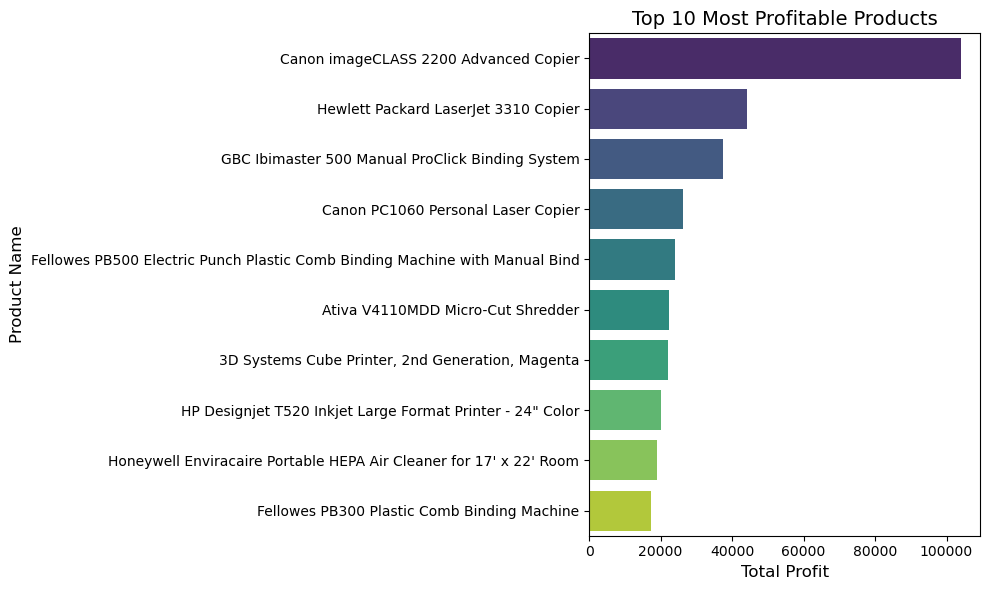

In [56]:
# 1) Top 10 Profitable Products -- GEMINI

product_profit = df.groupby('Product Name')['Total Profit'].sum().reset_index()

top_profitable = product_profit.sort_values(by='Total Profit', ascending=False).head(10)

# Visualization: Top 10 Profitable Products
plt.figure(figsize=(10, 6))
sns.barplot(x='Total Profit', y='Product Name', data=top_profitable, palette='viridis')
plt.title('Top 10 Most Profitable Products', fontsize=14)
plt.xlabel('Total Profit', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.savefig('top_10_profitable_products.png')


**Insight:**

High-end office machinery, particularly Copiers and Binding Systems, are the primary profit drivers. The Canon imageCLASS 2200 stands out as the most lucrative product by a significant margin.

C:\Users\Vivek\AppData\Local\Temp\ipykernel_10612\644179674.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Profit', y='Product Name', data=top_loss_making, palette='magma')


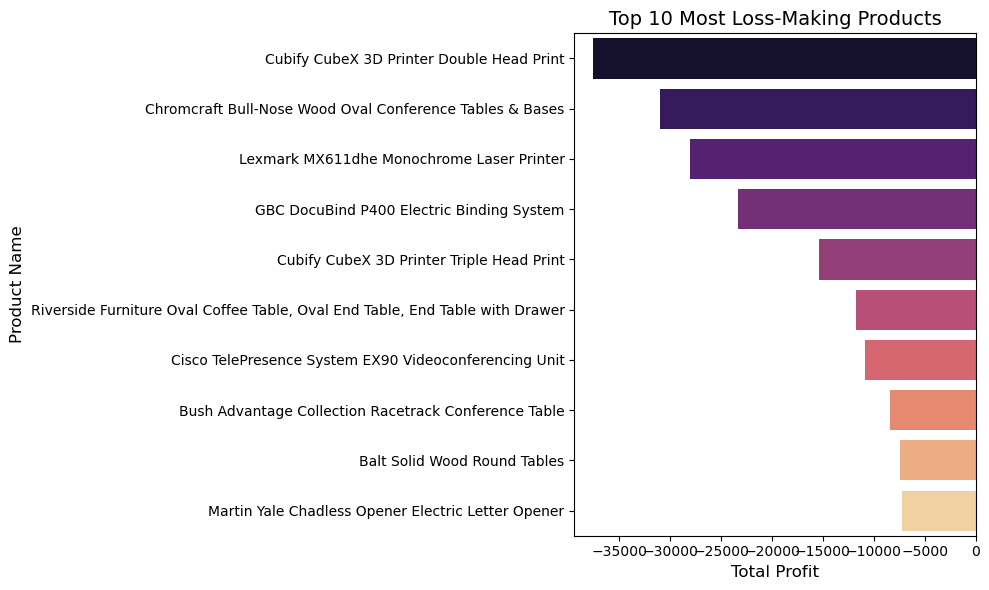

In [57]:
# 2) Top 10 Loss-Making Products
top_loss_making = product_profit.sort_values(by='Total Profit', ascending=True).head(10)
# Visualization: Top 10 Loss-Making Products
plt.figure(figsize=(10, 6))
sns.barplot(x='Total Profit', y='Product Name', data=top_loss_making, palette='magma')
plt.title('Top 10 Most Loss-Making Products', fontsize=14)
plt.xlabel('Total Profit', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.savefig('top_10_loss_making_products.png')

**Insight:**
The greatest losses are concentrated in 3D Printers and Large Furniture (Tables). The Cubify CubeX 3D Printer and Chromcraft Wood Tables show the highest total losses, suggesting that high revenue from these items is being offset by extreme costs or aggressive discounting.

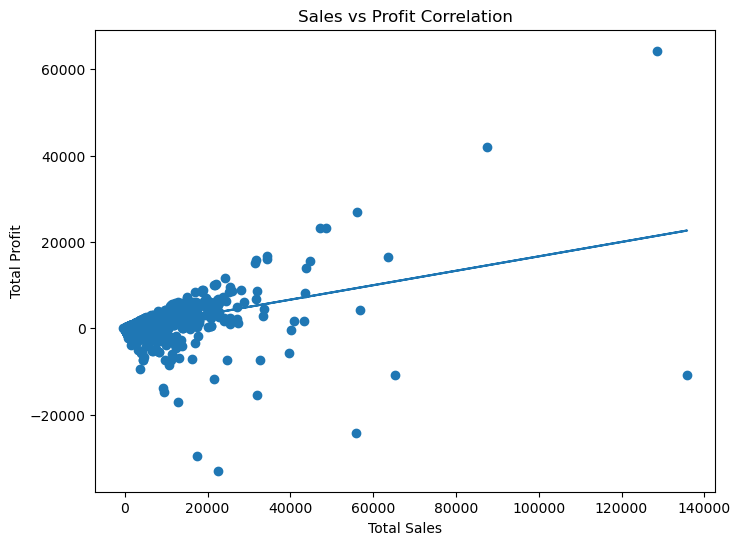

In [85]:
# 3) Sales vs Profit Correlation (Scatter + Regression Line)
# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df['Total Sales'], df['Total Profit'])

# Regression line
m, b = np.polyfit(df['Total Sales'], df['Total Profit'], 1)
plt.plot(df['Total Sales'], m*df['Total Sales'] + b)

plt.title('Sales vs Profit Correlation')
plt.xlabel('Total Sales')
plt.ylabel('Total Profit')
plt.savefig('Sales vs Profit Correlation')
plt.show()


**Insight:**

While sales and profit are positively related, the moderate correlation and high variability indicate that increasing sales alone is not sufficient to maximize profitability. The business must focus on optimizing pricing, controlling discounts, and managing costs to ensure that revenue growth translates into actual profit.



In [59]:
# Correlation Value
df[['Total Sales', 'Total Profit']].corr()


,Total Sales,Total Profit
Total Sales,1.000000,0.468951
Total Profit,0.468951,1.000000


**Insight:**

The dataset shows a moderate positive correlation (0.47) between Sales and Profit. This reveals that while increasing revenue generally improves the bottom line, the business is highly sensitive to external costs (like discounts and logistics). To maximize profitability, the strategy should shift from 'driving volume' to 'optimizing margins,' particularly in categories where the correlation is weakest.

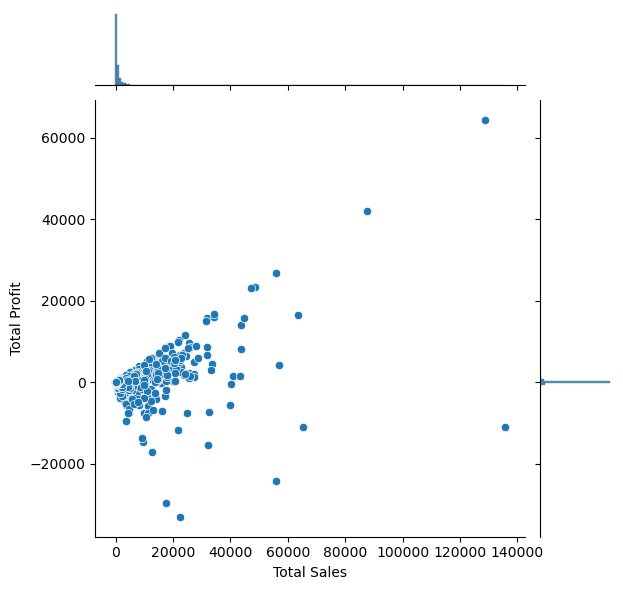

In [60]:
# 4) Joint Distribution (Sales vs Profit)

sns.jointplot(
    x='Total Sales',
    y='Total Profit',
    data=df,
    kind='scatter'
)

**Insight:**

**Dense Core:** The vast majority of transactions are concentrated in the low-sales, low-profit region ($< \$1,000$), forming the stable "bread and butter" of the business.

**Profit Volatility:** As Sales increase, the distribution "fans out." This indicates that higher revenue does not guarantee higher profit; instead, it increases the variance, leading to both the business's largest gains and its most severe losses.

**Skewness:** Both marginal distributions are heavily right-skewed, meaning the overall financial performance is disproportionately driven by a few high-value "outlier" transactions.





<span style="color:Green">

**(II) Customer Segmentation and Analysis**

</span>

<span style="color:red">

1. Customer Sales Quintile vs. Customer Profit Quintile: Create a heatmap or cross-tabulation to explore the relationship between customers' sales and profit quintiles. This will help identify which segments of customers are most valuable.

2. Understand how different product categories perform across customer segments: Create a pivot table to analyze the total Sales and total Profit by Category and Segment. Sort the pivot table to highlight the most profitable and least profitable combinations of Category and Segment.


</span>

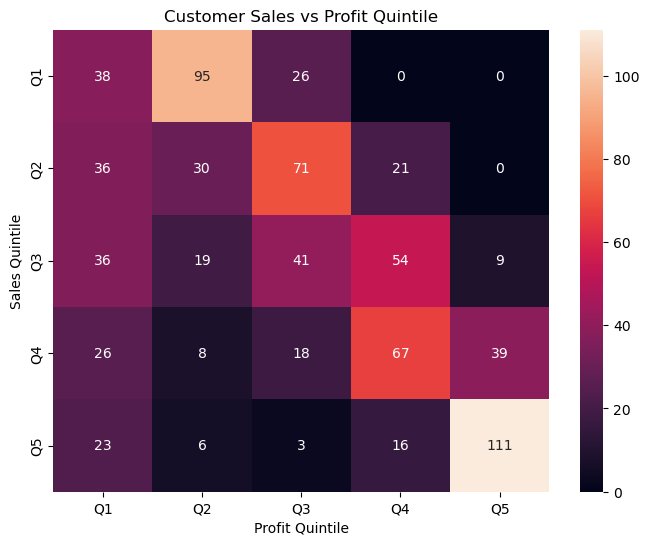

In [88]:
# 1) Customer Sales Quintile vs Profit Quintile (Heatmap)

crosstab = pd.crosstab(
    customer_metrics['Sales Quintile'],
    customer_metrics['Profit Quintile']
)
plt.figure(figsize=(8,6))
sns.heatmap(crosstab, annot=True, fmt='d')

plt.title('Customer Sales vs Profit Quintile')
plt.xlabel('Profit Quintile')
plt.ylabel('Sales Quintile')
plt.savefig('Customer Sales vs Profit Quintile')
plt.show()


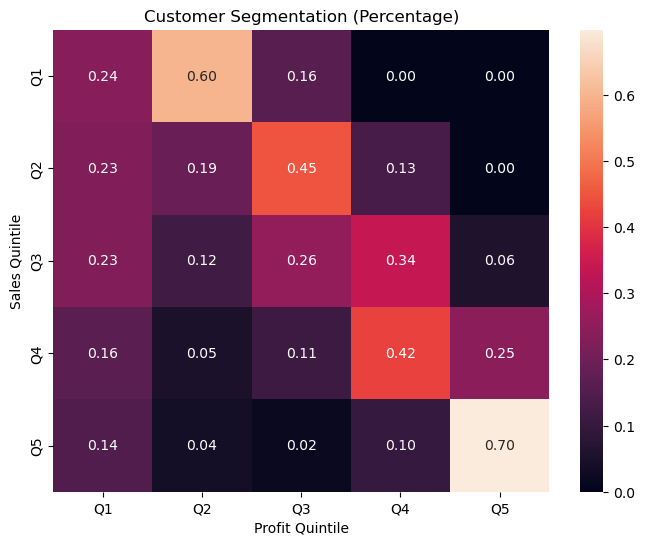

In [62]:
# Normalized Heatmap (Better Insight)
crosstab_pct = pd.crosstab(
    customer_metrics['Sales Quintile'],
    customer_metrics['Profit Quintile'],
    normalize='index'
)

plt.figure(figsize=(8,6))
sns.heatmap(crosstab_pct, annot=True, fmt='.2f')

plt.title('Customer Segmentation (Percentage)')
plt.xlabel('Profit Quintile')
plt.ylabel('Sales Quintile')
plt.show()

**Insight:**

**Q5 Sales & Q5 Profit** → Best customers

**Q5 Sales & Q1/Q2 Profit** → High revenue, low margin (discount problem)

**Q1 Sales & Q5 Profit** → High-margin niche customers

**Q1 & Q1** → Low-value segment

In [63]:
# 2) Category vs Segment Analysis (Pivot Table)
# Create Pivot Table
pivot_table = pd.pivot_table(
    df,
    values=['Total Sales', 'Total Profit'],
    index='Category',
    columns='Segment',
    aggfunc='sum'
)

display(pivot_table)

Total Profit                             Total Sales  \
Segment             Consumer    Corporate  Home Office      Consumer   
Category                                                               
Furniture         44207.2601   39847.2854   25563.7902  2056888.1798   
Office Supplies  278930.6843  202580.1575  127139.8968   1784905.802   
Technology       342580.3775  227346.3173  141533.0465   1966130.071   

                                            
Segment             Corporate  Home Office  
Category                                    
Furniture        1150449.0636  658002.5575  
Office Supplies   1157554.786   597855.788  
Technology        1213312.873   906437.717

In [64]:
# Sort categories by total profit

pivot_table = pd.pivot_table(
    df,
    values=['Total Sales', 'Total Profit'],
    index='Category',
    columns='Segment',
    aggfunc='sum'
)

# Add total profit column
pivot_table['Total Profit Sum'] = pivot_table['Total Profit'].sum(axis=1)

# Sort
pivot_table_sorted = pivot_table.sort_values(
    by='Total Profit Sum',
    ascending=False
)

display(pivot_table_sorted)

Total Profit                             Total Sales  \
Segment             Consumer    Corporate  Home Office      Consumer   
Category                                                               
Technology       342580.3775  227346.3173  141533.0465   1966130.071   
Office Supplies  278930.6843  202580.1575  127139.8968   1784905.802   
Furniture         44207.2601   39847.2854   25563.7902  2056888.1798   

                                           Total Profit Sum  
Segment             Corporate  Home Office                   
Category                                                     
Technology        1213312.873   906437.717      711459.7413  
Office Supplies   1157554.786   597855.788      608650.7386  
Furniture        1150449.0636  658002.5575      109618.3357

**Insights:**
**1. Customer Sales vs. Profit Quintiles (Heatmap)**
   
- **Champion Segment (Top-Right):** Customers in Sales Quintile 5 / Profit Quintile 5 are your most valuable assets—high revenue and high margin.

- **Leakage Segment (Top-Left):** A small but critical group of high-sales customers (Quintile 5) fall into low-profit quintiles (1-2). These customers are likely over-discounted or high-cost-to-serve.

- **Linear Growth:** The strong diagonal trend confirms that, for most customers, increasing sales volume successfully translates into higher profit tiers.

**2. Category vs. Segment Performance**
   
- The pivot analysis highlights where the business is most "efficient" at generating profit.

- **Primary Profit Engines:** The Technology category in the Consumer segment is the single most profitable combination.

- **Efficiency Leaders:** Technology and Office Supplies consistently deliver high profits across all segments (Consumer, Corporate, Home Office).

- **Underperformers:** The Furniture category is the least profitable across all segments. Despite having high sales volume (comparable to Office Supplies), its contribution to profit is significantly lower, indicating high overhead or low margins.

<span style="color:Green">

**(III) Shipping and Delivery Analysiss**

</span>

<span style="color:red">

1) Distribution of Shipping Urgency: Visualize the distribution of orders by Shipping Urgency using a pie chart or bar chart.

2) Days to Ship vs. Profit: Use a violin plot to explore the distribution of Profit across different Days to Ship categories. This will help analyze whether faster shipping correlates with higher or lower profitability.

3) Shipping Mode and Profitability: Create a grouped bar chart to compare the profitability of different shipping modes (e.g., Standard Class, First Class).

4) Using pivot table, determine which shipping modes are most preferred across different regions and analyze the impact on total sales and profit. Create a pivot table that shows the count of Order IDs, total Sales, and total Profit for each Region and Ship Mode. Identify and print your insights.

</span>

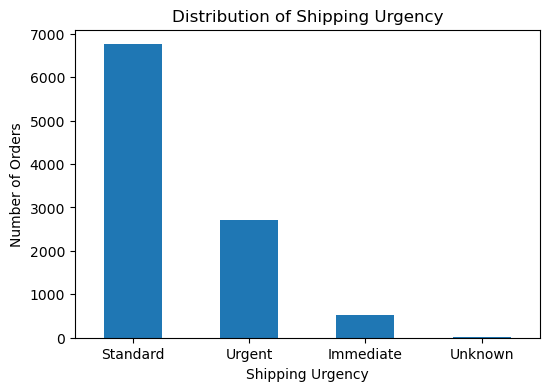

In [89]:
# 1) Distribution of Shipping Urgency
# Bar Chart (recommended over pie for clarity)
urgency_counts = df['Shipping Urgency'].value_counts()

plt.figure(figsize=(6,4))
urgency_counts.plot(kind='bar')
plt.title('Distribution of Shipping Urgency')
plt.xlabel('Shipping Urgency')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.savefig('Distribution of Shipping Urgency ')
plt.show()


**Insight:**

- Most orders are concentrated in standard/low urgency categories, indicating customers prefer cost-effective shipping over speed.

- High-urgency orders form a smaller proportion, showing limited demand for fast delivery.

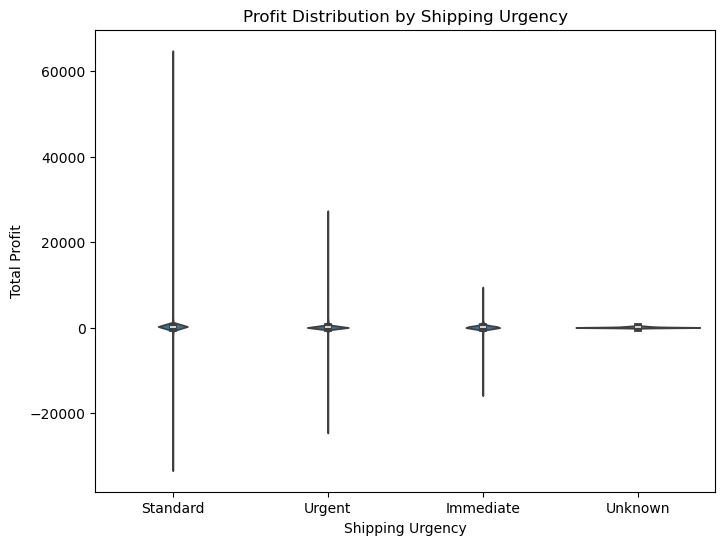

In [66]:
# 2) Days to Ship vs Profit (Violin Plot)

#👉 Use categorized shipping urgency (cleaner than raw days)


plt.figure(figsize=(8,6))
sns.violinplot(
    x='Shipping Urgency',
    y='Total Profit',
    data=df
)

plt.title('Profit Distribution by Shipping Urgency')
plt.xlabel('Shipping Urgency')
plt.ylabel('Total Profit')
plt.show()

**Insights:**

- Profit Consistency: Across all urgency levels (Standard, Urgent, Immediate), the profit distribution is heavily concentrated around zero, with similar spread patterns.

- High-Risk/High-Reward: The "Standard" urgency category exhibits the widest range of outliers (extreme profits and extreme losses), likely because high-value, complex orders are often shipped using standard logistics to save on costs.

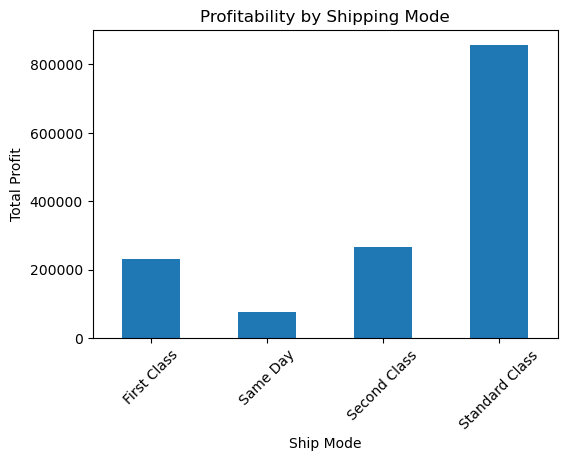

In [91]:
# 3) Shipping Mode vs Profitability (Grouped Bar Chart)
# Aggregate profit by Ship Mode

shipmode_profit = df.groupby('Ship Mode')['Total Profit'].sum()

plt.figure(figsize=(6,4))
shipmode_profit.plot(kind='bar')

plt.title('Profitability by Shipping Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.savefig('Profitability_of_Shipping_Mode.png', dpi=300, bbox_inches='tight')
plt.show()

**Insights :**
- Primary Contributor: Standard Class is the powerhouse of the business, generating the highest total profit ($857,470), far exceeding other modes.

- Low Volume, Low Impact: Same Day shipping contributes the least to overall profit, reflecting its status as a niche, premium service with higher operational costs.

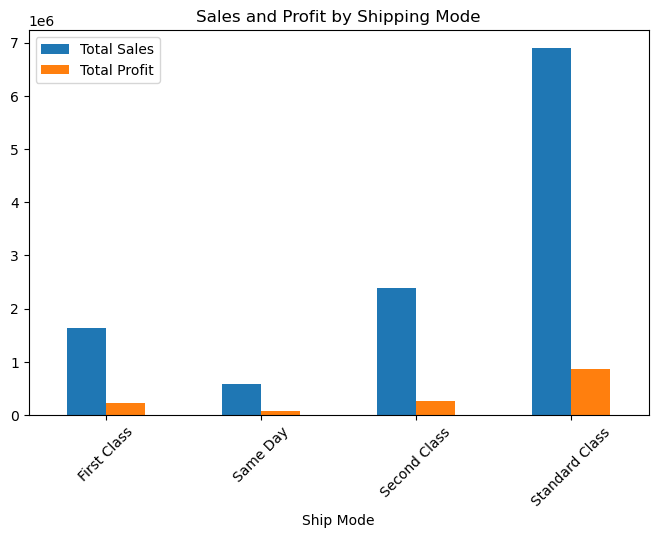

In [68]:
#(Sales + Profit together):
shipmode_summary = df.groupby('Ship Mode')[['Total Sales', 'Total Profit']].sum()

shipmode_summary.plot(kind='bar', figsize=(8,5))
plt.title('Sales and Profit by Shipping Mode')
plt.xticks(rotation=45)
plt.show()

In [69]:
# 4) Pivot Table: Region × Ship Mode Analysis
#Step 1: Create Pivot Table
pivot_shipping = pd.pivot_table(
    df,
    index='Region',
    columns='Ship Mode',
    values=['Order ID', 'Total Sales', 'Total Profit'],
    aggfunc={
        'Order ID': 'count',
        'Total Sales': 'sum',
        'Total Profit': 'sum'
    }
)

display(pivot_shipping)

Order ID                                      Total Profit  \
Ship Mode First Class Same Day Second Class Standard Class  First Class   
Region                                                                    
Central           301      120          465           1440    3789.6001   
East              492      155          532           1673   92349.5564   
South             233       83          330            976   32188.3244   
West              518      185          625           1874  101805.3357   

                                                   Total Sales              \
Ship Mode    Same Day Second Class Standard Class  First Class    Same Day   
Region                                                                       
Central     8152.7979   47510.6009    158596.2551  272819.9074   88764.084   
East       35834.1418   50525.1428    272339.4223   547773.511  194830.102   
South       -5275.936   58981.4851     141967.671    223956.72   97285.791   
West       36869.5142  109528.7288    284566.1751  587412.1195  206854.698   

                                       
Ship Mode Second Class Standard Class  
Region                                 
Central    504529.0898   1613656.8552  
East        608783.988    2032103.317  
South      546993.8695   1176573.8455  
West       720362.1025   2068836.8375

In [70]:
# Flatten Columns (for readability)
pivot_shipping.columns = ['_'.join(col) for col in pivot_shipping.columns]
pivot_shipping = pivot_shipping.reset_index()
pivot_shipping

,Region,Order ID_First Class,Order ID_Same Day,Order ID_Second Class,Order ID_Standard Class,Total Profit_First Class,Total Profit_Same Day,Total Profit_Second Class,Total Profit_Standard Class,Total Sales_First Class,Total Sales_Same Day,Total Sales_Second Class,Total Sales_Standard Class
0,Central,301,120,465,1440,3789.6001,8152.7979,47510.6009,158596.2551,272819.9074,88764.084,504529.0898,1613656.8552
1,East,492,155,532,1673,92349.5564,35834.1418,50525.1428,272339.4223,547773.511,194830.102,608783.988,2032103.317
2,South,233,83,330,976,32188.3244,-5275.936,58981.4851,141967.671,223956.72,97285.791,546993.8695,1176573.8455
3,West,518,185,625,1874,101805.3357,36869.5142,109528.7288,284566.1751,587412.1195,206854.698,720362.1025,2068836.8375


**Insight**:

- Preference Trend: Across all four regions (Central, East, South, West), Standard Class is consistently the most preferred shipping mode by both order count and total sales.

- Regional Performance Leader: The West Region is the most profitable across almost all shipping categories, particularly in Standard Class ($284,566).

- Strategic Observation: Same Day shipping in the South Region is currently loss-making (-$5,276), suggesting that the logistical costs of rapid delivery in this region outweigh the revenue generated.


<span style="color:Green">

**(IV) Regional Sales and Profitability**

</span>

<span style="color:red">

1) Sales and Profit by Region: Use a map or bar chart to visualize total sales and profit by region or state. This will highlight which regions are the most profitable.

2) State-wise Profitability: Create a pivot table to summarize the profitability of each state. Highlight the top and bottom states based on profitability.

3) Correlation between State and Profit: Use a correlation plot to identify any patterns or relationships between the states and the profitability of orders. (Hint: Convert the categorical 'State' column into numerical values using label encoding using “from sklearn.preprocessing import LabelEncoder”)

</span>

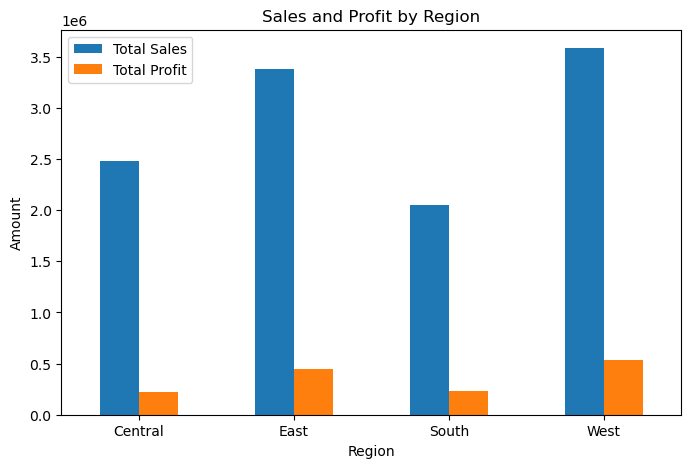

In [71]:
# 1) Sales and Profit by Region

region_summary = df.groupby('Region')[['Total Sales', 'Total Profit']].sum()

region_summary.plot(kind='bar', figsize=(8,5))
plt.title('Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()



**Insight:**

- The West Region is the business leader, generating both the highest total sales and the highest total profit. 

- While the Central Region has higher sales than the South, it is the least profitable region overall. This suggests that the Central region may be facing higher operational costs or deeper discounting strategies compared to others.

In [72]:
# 2) State-wise Profitability (Pivot Table)
state_profit = pd.pivot_table(
    df,
    values='Total Profit',
    index='State',
    aggfunc='sum'
)

# Sort to find Top & Bottom States
# Top 10 states
top_states = state_profit.sort_values(by='Total Profit', ascending=False).head(10)

# Bottom 10 states
bottom_states = state_profit.sort_values(by='Total Profit').head(10)

print("Top States:\n", top_states)
print("\nBottom States:\n", bottom_states)

Top States:
             Total Profit
State                   
California   378061.1197
New York     367514.4074
Washington    166626.697
Michigan     146948.9346
Virginia      99057.1736
Indiana       89085.4907
Georgia       78563.7237
Kentucky      58908.6024
Minnesota     49259.1076
New Jersey    47826.6894

Bottom States:
                 Total Profit
State                       
Texas           -135047.1019
Pennsylvania     -82830.3754
Ohio              -80553.575
Illinois         -59272.5775
North Carolina   -45731.0934
Colorado         -33819.2283
Tennessee        -31613.6966
Arizona           -17701.366
Florida          -17057.8711
Oregon            -4269.2273


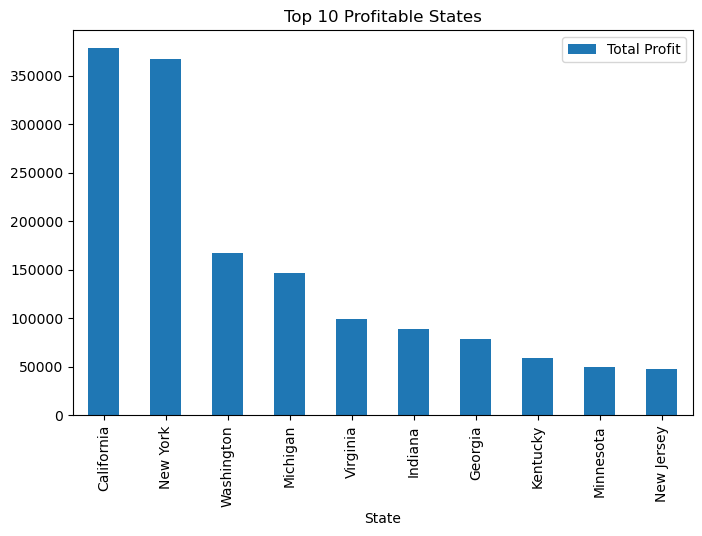

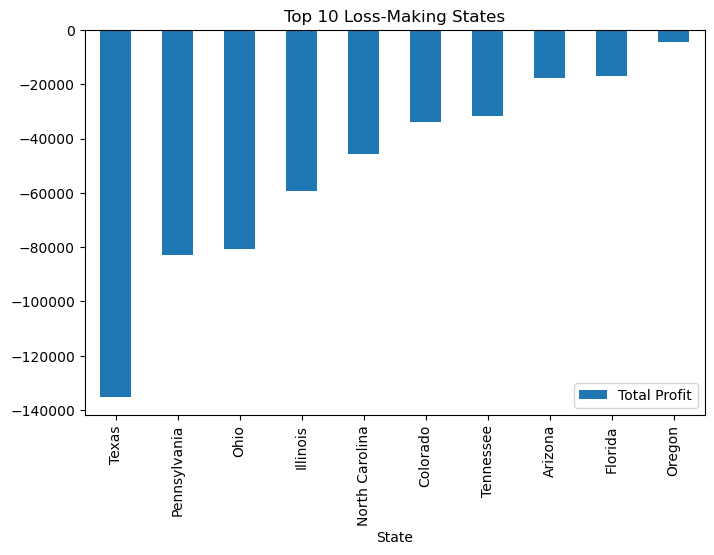

In [73]:
top_states.plot(kind='bar', figsize=(8,5))
plt.title('Top 10 Profitable States')
plt.show()

bottom_states.plot(kind='bar', figsize=(8,5))
plt.title('Top 10 Loss-Making States')
plt.show()

**Insight:**
- Top Performers: California and New York are the massive engines of profit, together contributing over $745,000. These states represent mature markets with high volume and healthy margins.

- Bottom Performers: Texas, Pennsylvania, and Ohio are the most significant "loss centers." Despite potentially high sales volumes, these states are suffering from negative profitability, likely due to aggressive local competition or high tax/shipping overheads.

               State Encoded  Total Profit
State Encoded       1.000000     -0.019897
Total Profit       -0.019897      1.000000


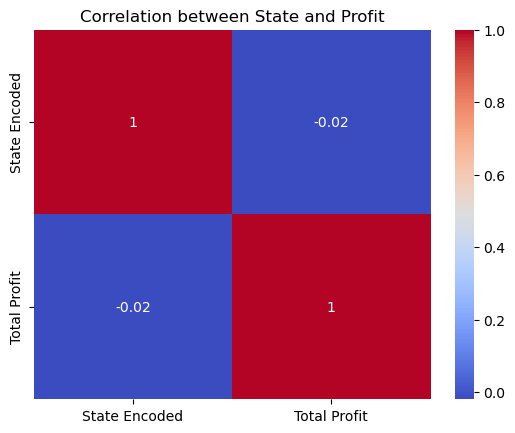

In [74]:
# 3) Correlation between State and Profit
# Step 1: Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['State Encoded'] = le.fit_transform(df['State'])

# Step 2: Correlation Calculation
correlation = df[['State Encoded', 'Total Profit']].corr()
print(correlation)

# Step 3: Heatmap

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation between State and Profit')
plt.show()

**Insight:**

- The correlation between encoded state and profit is very weak / insignificant.

- This suggests that profitability is not directly dependent on location alone, but influenced by other factors like discounts, category, and customer segment.

<span style="color:Green">

**(V) Discount and Pricing Analysis**

</span>

<span style="color:red">

1) Impact of Discounts on Profitability: Use a scatter plot with a trend line to analyze how different levels of discount affect profitability.

2) Original Price vs. Discounted Price: Create a line plot to compare the original price and the discounted price across various product categories or sub-categories.

</span>

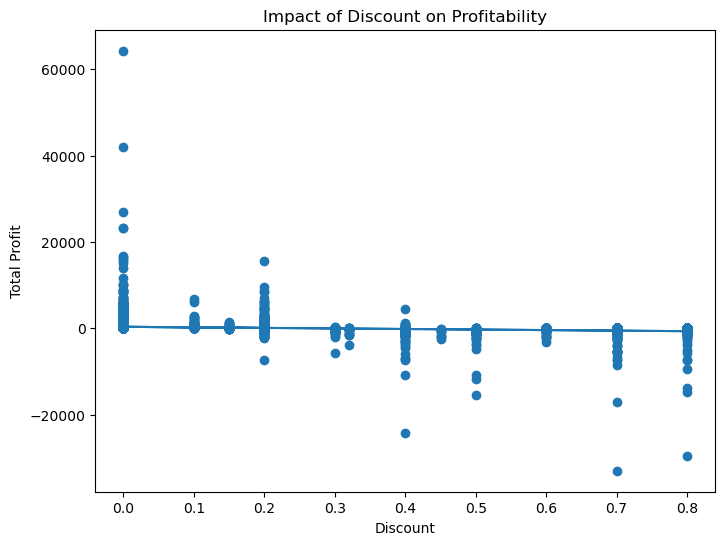

In [75]:
# 1) Impact of Discounts on Profitability (Scatter + Trend Line)

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df['Discount'], df['Total Profit'])

# Add regression (trend line)
m, b = np.polyfit(df['Discount'], df['Total Profit'], 1)
plt.plot(df['Discount'], m*df['Discount'] + b)

plt.title('Impact of Discount on Profitability')
plt.xlabel('Discount')
plt.ylabel('Total Profit')
plt.show()

**Insights:**

Downward slope → Higher discounts reduce profit

Flat trend → Discount has minimal impact

Mixed pattern → Depends on product/category

- The trend line shows a negative relationship between discount and profit.
- Higher discounts generally lead to lower or negative profitability.
- Excessive discounting is a key driver of loss-making transactions.

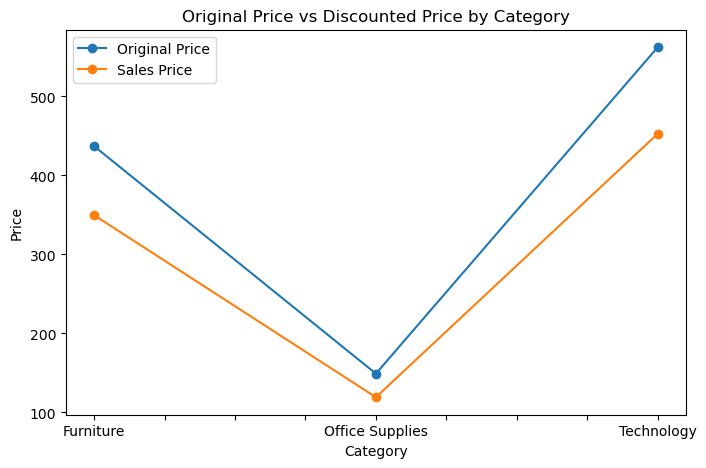

In [76]:
# 2) Original Price vs Discounted Price (Line Plot)

# aggregate by category or sub-category

# Step 1: Prepare Data

price_comparison = df.groupby('Category')[['Original Price', 'Sales Price']].mean()

# Step 2: Line Plot

price_comparison.plot(kind='line', marker='o', figsize=(8,5))

plt.title('Original Price vs Discounted Price by Category')
plt.xlabel('Category')
plt.ylabel('Price')
plt.xticks(rotation=0)
plt.show()

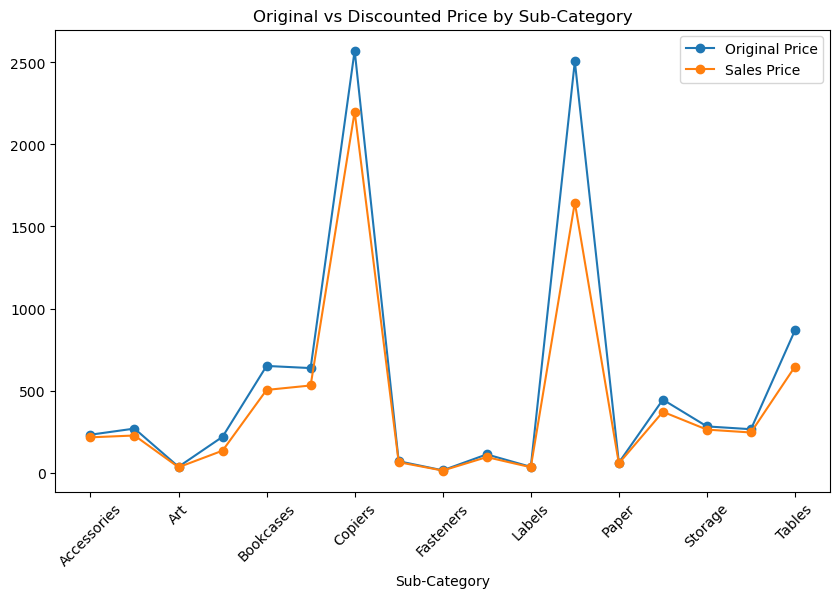

In [77]:
# Sub-Category wise Original Price vs Discounted Price (Line Plot)

price_comparison = df.groupby('Sub-Category')[['Original Price', 'Sales Price']].mean()

price_comparison.plot(figsize=(10,6), marker='o')
plt.xticks(rotation=45)
plt.title('Original vs Discounted Price by Sub-Category')
plt.show()

**Insight:**

- **Technology:** Highest value category with the largest absolute price gap (Avg. $562 \rightarrow \$453$). Despite this, it remains the most profitable category, indicating strong underlying margins.

- **Furniture:** Shows a significant price drop. Combined with the previous insight that Furniture has the lowest profitability, these discounts are likely deeper than the category's thin margins can handle.

- **Office Supplies:** The most stable pricing with the smallest gaps, reflecting its role as a consistent, low-volatility revenue source.

<span style="color:Green">

**(VI) Temporal Analysis**

</span>

<span style="color:red">

1) Sales and Profit Trends Over Time: Use a time series plot to analyze how sales and profit have trended over the years or months. This will help in identifying any seasonal patterns.

2) Order Frequency by Month: Use a bar chart or line plot to show the number of orders placed each month. Highlight any months with unusually high or low order frequencies.

3) Yearly Growth in Sales and Profit: Use a year-over-year growth chart to compare the sales and profit growth over different years.
</span>

C:\Users\Vivek\AppData\Local\Temp\ipykernel_10612\231282659.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = df.resample('M', on='Order Date')[['Total Sales', 'Total Profit']].sum()


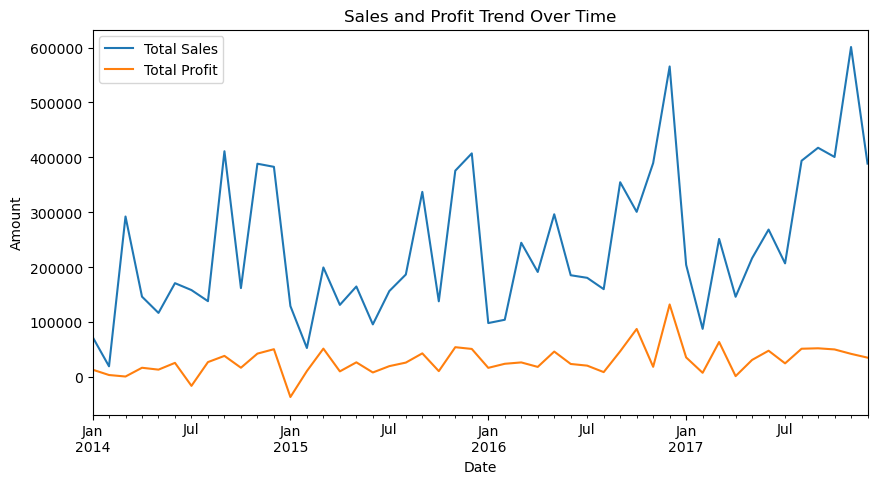

In [78]:
# 1) Sales & Profit Trends Over Time (Time Series)
# Step 1: Ensure Date Format

df['Order Date'] = pd.to_datetime(df['Order Date'])

# Step 2: Aggregate by Month (recommended)
monthly_trend = df.resample('M', on='Order Date')[['Total Sales', 'Total Profit']].sum()

# Step 3: Plot Time Series
monthly_trend.plot(figsize=(10,5))

plt.title('Sales and Profit Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.show()

**Insight:**

- **End-of-Year Surge:** Sales consistently spike in November and December, likely driven by holiday shopping and year-end corporate budget clear-outs.

- **Profit Lag:** While sales peaked dramatically in November 2017, profits did not follow the same trajectory, suggesting heavy discounting or higher operational costs during the peak season.


  

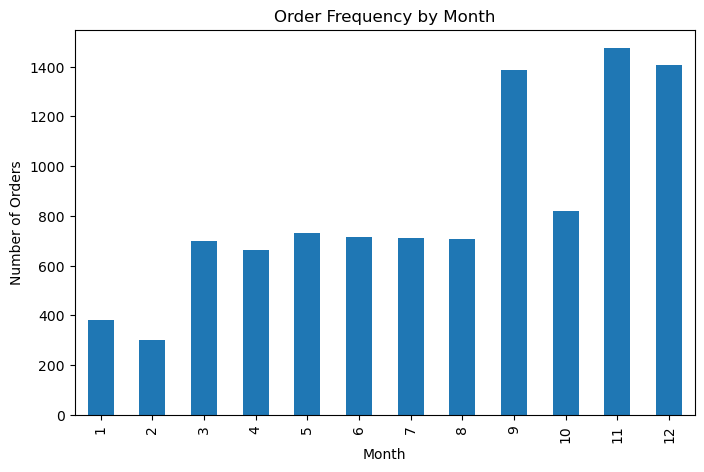

In [79]:
# 2) Order Frequency by Month
# Step 1: Extract Month
df['Month'] = df['Order Date'].dt.month
monthly_orders = df.groupby('Month')['Order ID'].count()
# Step 3: Plot
monthly_orders.plot(kind='bar', figsize=(8,5))

plt.title('Order Frequency by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

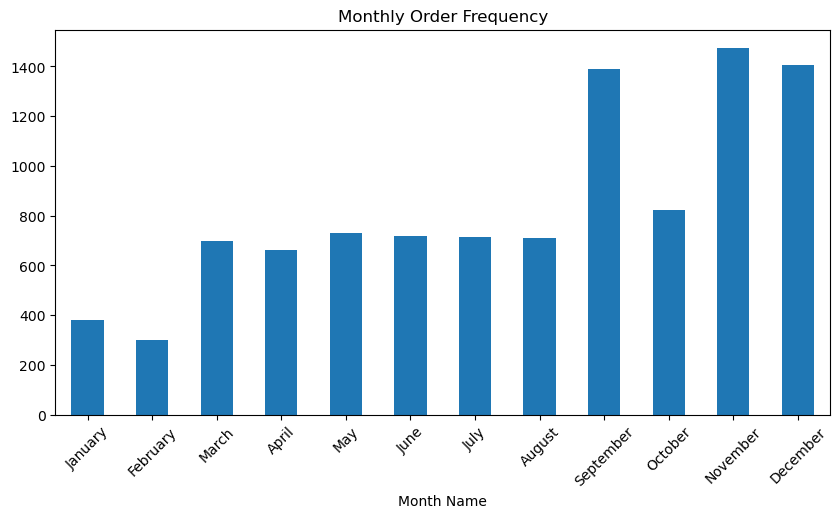

In [80]:
# Better (Month Names for readability)
df['Month Name'] = df['Order Date'].dt.month_name()

monthly_orders = df.groupby('Month Name')['Order ID'].count()

monthly_orders = monthly_orders.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

monthly_orders.plot(kind='bar', figsize=(10,5))
plt.title('Monthly Order Frequency')
plt.xticks(rotation=45)
plt.show()

**Insights:**

**High Volume Season:** September, November, and December are the busiest months, each seeing over 1,300+ orders. This tri-peak pattern suggests a strong "Back-to-School" (Sept) and "Holiday" (Nov/Dec) influence.

**Slow Start:** January and February are the quietest months (~300-380 orders), indicating a significant post-holiday slump that requires strategic promotions to sustain cash flow.





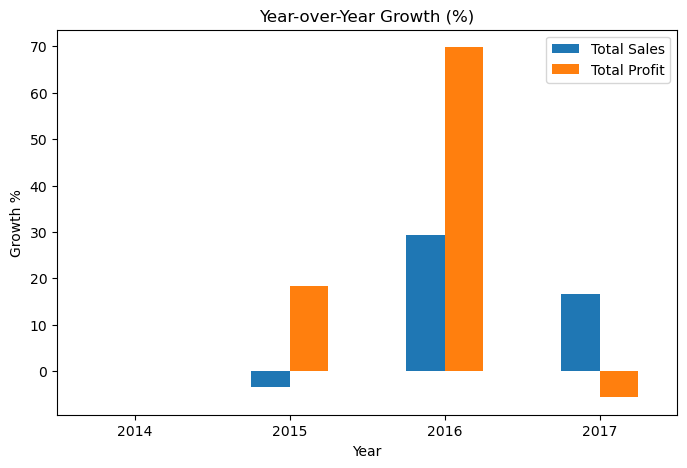

In [81]:
# 3) Year-over-Year Growth (YoY Analysis)
# Step 1: Extract Year
df['Year'] = df['Order Date'].dt.year

# Step 2: Aggregate Yearly Data
yearly_data = df.groupby('Year')[['Total Sales', 'Total Profit']].sum()

# Step 3: Calculate Growth (%)
growth = yearly_data.pct_change() * 100

# Step 4: Plot Growth
growth.plot(kind='bar', figsize=(8,5))

plt.title('Year-over-Year Growth (%)')
plt.xlabel('Year')
plt.ylabel('Growth %')
plt.xticks(rotation=0)
plt.show()

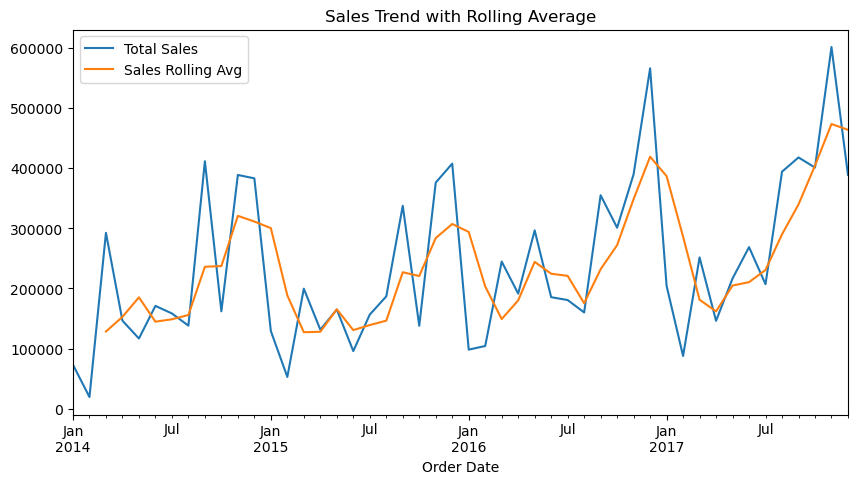

In [82]:
# Add rolling average for smoother trend:
monthly_trend['Sales Rolling Avg'] = monthly_trend['Total Sales'].rolling(3).mean()

monthly_trend[['Total Sales', 'Sales Rolling Avg']].plot(figsize=(10,5))
plt.title('Sales Trend with Rolling Average')
plt.show()

**Insights:**

**Explosive 2016:** This was the "Golden Year" where sales grew by 29% and profit skyrocketed by nearly 70%.

**The 2017 Efficiency Gap:** In 2017, despite sales growing by 16%, profit actually contracted by 5.6%.

**Insight:** The company is successfully growing its market share (revenue), but the cost of acquiring that revenue (or the level of discounting used) significantly eroded the bottom line in the most recent year.

<span style="color:red">**==============================================================================================================**</span>


**Overall Insights & Conclusion**

- The business shows steady sales growth, but profitability is inconsistent and highly influenced by discounts and costs.
- A moderate sales–profit relationship indicates that increasing sales alone does not guarantee higher profit.
- Heavy discounting is a major factor reducing profitability, with several transactions and products generating losses.
- Profit is concentrated in a few products, customers, regions, and segments, while others underperform.
- Standard shipping and certain regions drive most of the revenue and profit, whereas faster shipping and some locations reduce margins.
- Clear seasonal trends exist, with specific months contributing significantly to sales and order volume.

**Final Recommendation**

To improve overall performance, the business should focus on optimizing discount strategies, promoting high-margin products, targeting profitable customer segments, and controlling operational costs, ensuring that sales growth translates into sustainable profitability.

                                                               Thank You